In [2]:
# [담당자: 정찬성] 신용카드 사기검출 데이터셋 로드
# 왜: creditcard.csv는 유럽 카드사의 실제 거래 데이터를 PCA로 익명화한 데이터로,
#     V1~V28은 이미 주성분(PCA) 변환이 끝난 값이라 별도 인코딩이 필요 없다.
#     경고(warning) 문구가 뒤에서 반복 출력되면 결과 확인이 번거로워
#     분석 초반에 한 번만 무시 처리해 둔다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


card_df = pd.read_csv('../data/creditcard.csv')
card_df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [3]:
# 왜: 컬럼별 데이터 타입/결측 여부를 한 번에 확인해, 이후 전처리에서 타입 변환이나
#     결측치 처리가 필요한지 먼저 파악한다.
card_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
# 왜: info()의 Non-Null Count로도 결측 여부를 알 수 있지만, 전체 결측치 합계를
#     한 번 더 명시적으로 확인해 "결측치 처리" 단계를 생략해도 되는지 근거를 남긴다.
# 컬럼별 결측치 개수
# card_df.isna().sum()

# 전체 결측치 개수
card_df.isna().sum().sum()

np.int64(0)

In [5]:
# 왜: Amount는 분포 왜곡(치우침)이 심하고 V1~V28은 스케일이 서로 다른데,
#     이 사실을 describe()의 평균/표준편차/최댓값으로 먼저 눈으로 확인해야
#     뒤에서 다룰 "Amount 정규화" 단계의 필요성을 근거를 갖고 설명할 수 있다.
card_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
from sklearn.model_selection import train_test_split


# 왜: Time은 거래 발생 후 경과 초(sequential id 성격)일 뿐 사기 여부와 직접적인
#     인과관계가 없어, 베이스라인 단계에서는 가장 먼저 제거 대상으로 삼는다.
#     이후 단계(표준화/로그변환)에서 이 함수를 다시 정의(재정의)하며 로직만 바꿔가는
#     방식으로, "무엇을 바꿨을 때 성능이 어떻게 변하는지"를 비교하기 쉽게 만든다.
# 인자로 입력받은 DataFrame을 복사 한 뒤 Time 컬럼만 삭제하고 복사된 DataFrame 반환
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)
    return df_copy

In [7]:
# 왜: get_preprocessed_df()를 함수 내부에서 호출하도록 감싸 두면, 이후 셀에서
#     get_preprocessed_df()의 "내용만" 다시 정의해도 이 함수와 호출부는 그대로
#     재사용할 수 있다. 또한 사기 거래(Class=1)가 전체의 0.17%뿐인 극단적 불균형
#     데이터라서, stratify=y_target 없이 무작위 분할하면 테스트셋의 사기 비율이
#     학습셋과 달라질 위험이 있어 반드시 층화 추출(stratify)로 분할한다.
# 사전 데이터 가공 후 학습과 테스트 데이터 세트를 반환하는 함수.
def get_train_test_dataset(df=None):
    # 인자로 입력된 DataFrame의 사전 데이터 가공이 완료된 복사 DataFrame 반환
    df_copy = get_preprocessed_df(df)
    # DataFrame의 맨 마지막 컬럼이 레이블, 나머지는 피처들
    X_features = df_copy.iloc[:, :-1]
    y_target = df_copy.iloc[:, -1]
    # train_test_split( )으로 학습과 테스트 데이터 분할. stratify=y_target으로 Stratified 기반 분할
    X_train, X_test, y_train, y_test = \
    train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)
    # 학습과 테스트 데이터 세트 반환
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

In [8]:
# 왜: stratify=y_target이 실제로 의도대로 동작했는지, 학습/테스트 세트의
#     사기(Class=1) 비율이 서로 비슷한지를 숫자로 검증한다.
print('학습 데이터 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0] * 100)
print('테스트 데이터 레이블 값 비율')
print(y_test.value_counts()/y_test.shape[0] * 100)

학습 데이터 레이블 값 비율
Class
0    99.827451
1     0.172549
Name: count, dtype: float64
테스트 데이터 레이블 값 비율
Class
0    99.826785
1     0.173215
Name: count, dtype: float64


In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score


# 왜: 이후 LR/LightGBM/XGBoost 세 모델과 5개 전처리 단계를 반복 평가해야 하므로,
#     평가지표 계산+출력 로직을 한 곳에 모아 두면 모델·단계가 바뀌어도 이 함수 하나만
#     재사용하면 된다. 정확도만으로는 불균형 데이터(사기 0.17%)의 실제 탐지력을 알 수
#     없어(전부 정상이라고만 찍어도 99.8% 정확도) 정밀도/재현율/F1/AUC까지 함께 본다.
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [10]:
# Base Model : LogisticRegression
from sklearn.linear_model import LogisticRegression


# 왜: 선형 모델인 로지스틱 회귀를 최소 가공 데이터에 먼저 적용해, 이후 추가할
#     LightGBM/XGBoost 같은 트리 기반 앙상블 모델과 성능을 비교할 "기준선(baseline)"으로
#     삼는다.
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:, 1]


# 3장에서 사용한 get_clf_eval() 함수를 이용하여 평가 수행.
get_clf_eval(y_test, lr_pred, lr_pred_proba)

오차 행렬
[[85281    14]
 [   54    94]]
정확도: 0.9992, 정밀도: 0.8704, 재현율: 0.6351,    F1: 0.7344, AUC:0.9617


In [11]:
# 왜: 매 모델·단계마다 "fit → predict → predict_proba → 평가출력"을 반복 작성하면
#     실수(오탈자, 인자 순서 등) 위험이 커진다. Estimator 인터페이스(fit/predict/predict_proba)를
#     따르는 모델이면 LR·LightGBM·XGBoost 무엇이든 이 함수 하나로 통일해서 평가할 수 있다.
# 인자로 사이킷런의 Estimator객체와, 학습/테스트 데이터 세트를 입력 받아서 학습/예측/평가 수행.
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    get_clf_eval(tgt_test, pred, pred_proba)

In [12]:
from lightgbm import LGBMClassifier


# 왜: boost_from_average=False는 LightGBM이 불균형 이진분류에서 초깃값을 평균으로
#     잡을 때 발생하는 경고/성능 저하를 막기 위한 LightGBM 고유의 권장 설정이다.
#     n_estimators=1000, num_leaves=64는 트리 개수와 리프 노드 수를 넉넉히 주어
#     복잡한 패턴(사기 탐지)을 잡아내되, n_jobs=-1로 학습 시간을 단축한다.
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013607 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

In [13]:
# [담당자: 정찬성 / 모델: XGBoost] 베이스 모델 평가 (가공 전 데이터)
# 왜: LR(선형)과 LightGBM(리프 중심 트리) 두 계열과 비교하기 위해, 같은 그래디언트
#     부스팅 계열이지만 트리 성장 방식이 다른(레벨/깊이 중심) XGBoost를 3번째 모델로
#     추가한다. max_depth=3 + learning_rate=0.05로 얕은 트리를 많이(1000그루) 쌓아
#     과적합을 억제하면서 LightGBM(num_leaves=64)과 비슷한 모델 복잡도를 맞춰, 이후
#     단계별 성능 변화가 "전처리 효과"인지 "하이퍼파라미터 차이"인지 헷갈리지 않게
#     한다. eval_metric='logloss'는 최신 XGBoost(2.0+)에서 use_label_encoder 관련
#     경고 없이 이진분류 로그손실 기준으로 학습하기 위한 명시적 지정이다.
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05,
                         n_jobs=-1, random_state=42, eval_metric='logloss')
get_model_train_eval(xgb_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

오차 행렬
[[85289     6]
 [   36   112]]
정확도: 0.9995, 정밀도: 0.9492, 재현율: 0.7568,    F1: 0.8421, AUC:0.9837


In [14]:
# LightGBM
# 오차 행렬
# [[85290     5]
#  [   36   112]]
# 정확도: 0.9995, 정밀도: 0.9573, 재현율: 0.7568,    F1: 0.8453, AUC:0.9790

# LogustucReg
# 오차 행렬
# [[85281    14]
#  [   54    94]]
# 정확도: 0.9992, 정밀도: 0.8704, 재현율: 0.6351,    F1: 0.7344, AUC:0.9617

# XGBoost [담당자: 정찬성]
# 오차 행렬
# [[85289     6]
#  [   36   112]]
# 정확도: 0.9995, 정밀도: 0.9492, 재현율: 0.7568,    F1: 0.8421, AUC:0.9837
# 왜 기록하는가: 세 모델의 "가공 전" 성능을 한 셀에 모아 두면, 이후 Amount 변환/
#   이상치 제거/오버샘플링을 적용했을 때 모델별로 얼마나 개선되는지 비교할 기준선이
#   된다. XGBoost는 LightGBM과 재현율(0.7568)이 동일하고 AUC는 오히려 더 높아(0.9837),
#   가공 전 단계에서는 두 부스팅 모델이 우열을 가리기 어려운 수준임을 확인했다.

---

### 데이터 가공 후 성능 평가
1. 데이터 분포 변환
2. 이상치 데이터 제거
3. 오버 샘플링

---

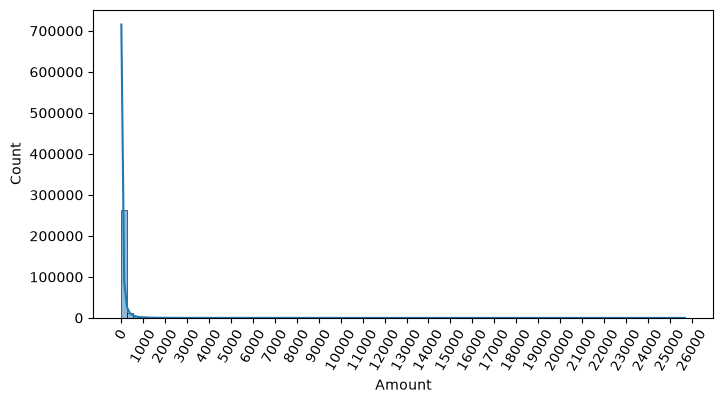

In [15]:
# 1. 데이터 분포 변환
# - Amount feature 분포 확인
# - 변환 : log 변환
# 분포 확인 : 시각화
import seaborn as sns


# 왜: Amount가 정규분포에서 얼마나 벗어나 있는지(오른쪽 꼬리가 긴 분포인지)를 눈으로
#     확인해야, 이어지는 "표준화 vs 로그변환" 두 가지 처리 방식을 시도해 볼 근거가 생긴다.
plt.figure(figsize=(8, 4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.histplot(card_df['Amount'], bins=100, kde=True)
plt.show()

In [16]:
# Amount feature를 StandardScaler : 표준화, LR
from sklearn.preprocessing import StandardScaler
# 왜: LR처럼 거리를 기반으로 하거나 정규화(regularization) 페널티가 걸리는 선형모델은
#     피처 스케일 차이에 민감하다. Amount는 0~25,691까지 값 범위가 V1~V28(대부분 -50~50)
#     보다 훨씬 커서, 표준화 없이 넣으면 LR이 Amount에 과도한 가중치를 줄 위험이 있다.
#     StandardScaler로 평균 0, 분산 1로 맞춰 이 위험을 없앤다.
# 사이킷런의 StandardScaler를 이용하여 정규분포 형태로 Amount 피처값 변환하는 로직으로 수정.
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))
    # 변환된 Amount를 Amount_Scaled로 피처명 변경후 DataFrame맨 앞 컬럼으로 입력
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    # 기존 Time, Amount 피처 삭제
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

In [17]:
# LR / LGBM 성능 확인
# Amount를 정규분포 형태로 변환 후 로지스틱 회귀 및 LightGBM 수행.
# 왜: 방금 재정의한 get_preprocessed_df()가 get_train_test_dataset() 내부에서
#     그대로 호출되므로, 이 셀만 다시 실행하면 "표준화된 Amount" 기준으로 데이터가
#     새로 만들어진다. LR은 스케일에 민감하니 개선 여부를, LightGBM은 트리 기반이라
#     스케일에 원래 둔감할 것이라는 가설을 함께 검증한다.
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)


print('### 로지스틱 회귀 예측 성능 ###')
lr_clf = LogisticRegression()
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)


print('### LightGBM 예측 성능 ###')
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
오차 행렬
[[85281    14]
 [   55    93]]
정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284,    F1: 0.7294, AUC:0.9706
### LightGBM 예측 성능 ###
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [18]:
# [담당자: 정찬성 / 모델: XGBoost] Amount 표준화 단계 평가
# 왜: XGBoost도 LightGBM과 마찬가지로 트리 분할 기준이 "값의 순서"만 사용하므로,
#     StandardScaler처럼 평균/분산만 바꾸는 단조 변환(monotonic transform)에는 성능이
#     이론적으로 변하지 않아야 한다. 이 가설이 실제로 맞는지 직접 확인하기 위해
#     같은 하이퍼파라미터로 재학습한다.
print('### XGBoost 예측 성능 ###')
xgb_clf = XGBClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05,
                         n_jobs=-1, random_state=156, eval_metric='logloss')
get_model_train_eval(xgb_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### XGBoost 예측 성능 ###
오차 행렬
[[85289     6]
 [   36   112]]
정확도: 0.9995, 정밀도: 0.9492, 재현율: 0.7568,    F1: 0.8421, AUC:0.9837


In [19]:
### 로지스틱 회귀 예측 성능 ###
# 오차 행렬
# [[85281    14]
#  [   55    93]]
# 정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284,    F1: 0.7294, AUC:0.9706

### LGBM 예측 성능 ###
# 오차 행렬
# [[85290     5]
#  [   37   111]]
# 정확도: 0.9995, 정밀도: 0.9569, 재현율: 0.7500,    F1: 0.8409, AUC:0.9779

### XGBoost 예측 성능 [담당자: 정찬성] ###
# 오차 행렬
# [[85289     6]
#  [   36   112]]
# 정확도: 0.9995, 정밀도: 0.9492, 재현율: 0.7568,    F1: 0.8421, AUC:0.9837
# 왜 기록하는가: 가공 전(Base) 결과와 소수점 넷째 자리까지 완전히 동일하다.
#   이는 "트리 기반 모델은 단조 변환에 불변"이라는 가설을 실측으로 뒷받침하는
#   근거이며, XGBoost에 한해서는 Amount 표준화 작업이 성능에 영향을 주지 않는다는
#   결론을 내릴 수 있다(LR은 미세하게 하락, 트리 모델 2종은 무변화).

In [20]:
# 왜: StandardScaler는 극단치(이상치)의 영향을 그대로 남겨 분산을 계산하지만,
#     log1p(=log(1+x))는 큰 값일수록 압축폭이 커져 오른쪽 꼬리가 긴 분포(Amount처럼)를
#     정규분포에 더 가깝게 만들어 준다. LR 입장에서 표준화보다 로그변환이 유리한지
#     비교하기 위해 get_preprocessed_df()를 다시 재정의한다.
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    # 넘파이의 log1p( )를 이용하여 Amount를 로그 변환
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

In [21]:
# 왜: 이번에도 새 lr_clf/lgbm_clf 객체를 만들지 않고 기존 객체를 재사용한다.
#     사이킷런/LightGBM의 fit()은 호출될 때마다 내부 상태를 초기화하고 처음부터 다시
#     학습하므로, 객체를 새로 만들지 않아도 이전 학습 결과가 섞이지 않는다.
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)


print('### 로지스틱 회귀 예측 성능 ###')
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)


print('### LightGBM 예측 성능 ###')
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
오차 행렬
[[85282    13]
 [   59    89]]
정확도: 0.9992, 정밀도: 0.8725, 재현율: 0.6014,    F1: 0.7120, AUC:0.9734
### LightGBM 예측 성능 ###
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [22]:
# [담당자: 정찬성 / 모델: XGBoost] log1p 변환 단계 평가
# 왜: log1p 역시 단조 변환이므로 XGBoost 성능은 표준화 단계와 동일할 것으로
#     예상된다. 원본 노트북의 패턴(같은 객체를 재사용해 fit)을 그대로 따라 xgb_clf도
#     재사용한다.
print('### XGBoost 예측 성능 ###')
get_model_train_eval(xgb_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### XGBoost 예측 성능 ###
오차 행렬
[[85289     6]
 [   36   112]]
정확도: 0.9995, 정밀도: 0.9492, 재현율: 0.7568,    F1: 0.8421, AUC:0.9837


In [23]:
# 2. 이상치 데이터 제거
# 이상치 검출 : 사분위 => IQR 사용해서 이상치 검출
# 피처와 답의 상관관계(중요도)
# 왜: 이상치를 아무 컬럼에서나 제거하면 안 되고, Class(사기 여부)와 상관관계가 높은
#     피처에서 제거해야 효과가 크다. 어떤 피처를 기준으로 이상치를 잡을지 정하기 위해
#     먼저 전체 피처 간 상관계수를 계산한다.
corr = card_df.corr()
corr

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447
V5,0.173072,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,...,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356,-0.094974
V6,-0.063016,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,...,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981,-0.043643
V7,0.084714,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,...,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311,-0.187257
V8,-0.036949,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,...,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079,0.019875
V9,-0.008660,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,...,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246,-0.097733


<Axes: >

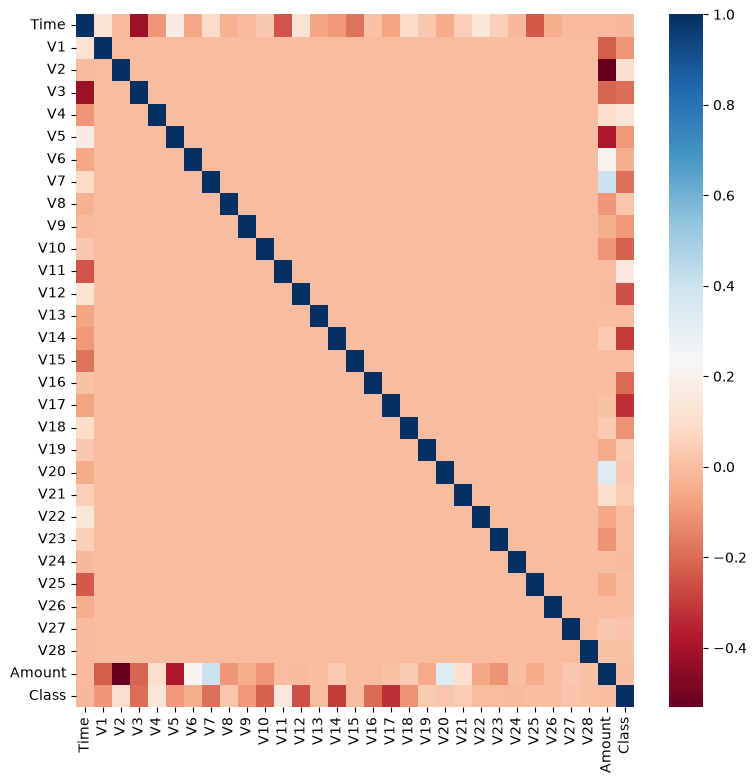

In [24]:
import seaborn as sns


# 왜: 숫자 표(corr)만으로는 30개 피처 간 관계를 한눈에 파악하기 어려워, 히트맵으로
#     시각화해 Class와 상관관계가 큰(색이 진한) 피처를 빠르게 찾는다. RdBu는 양의
#     상관관계와 음의 상관관계를 색으로 직관적으로 구분해 준다.
plt.figure(figsize=(9, 9))
corr = card_df.corr()
sns.heatmap(corr, cmap='RdBu')

In [25]:
import numpy as np


# 왜: 이상치를 "사기 거래(Class=1)" 안에서만 찾는 이유는, 정상 거래의 이상치까지
#     지우면 오히려 학습 데이터가 왜곡되기 때문이다. 사기 표본은 342건뿐이라 극단값
#     하나가 모델 학습에 미치는 영향이 크므로, 사분위수 기반 IQR 방식으로 사기 표본
#     안의 이상치만 골라낸다.
def get_outlier(df=None, column=None, weight=1.5):
    # fraud에 해당하는 column 데이터만 추출, 1/4 분위와 3/4 분위 지점을 np.percentile로 구함.
    fraud = df[df['Class']==1][column]
    quantile_25 = np.percentile(fraud.values, 25) # 25% 위치에 있는 값을 가져와라
    quantile_75 = np.percentile(fraud.values, 75) # 75% 위치에 있는 값을 가져와라
    # IQR을 구하고, IQR에 1.5를 곱하여 최대값과 최소값 지점 구함.
    iqr = quantile_75 - quantile_25
    iqr_weight = iqr * weight
    lowest_val = quantile_25 - iqr_weight
    highest_val = quantile_75 + iqr_weight
    # 최대값 보다 크거나, 최소값 보다 작은 값을 아웃라이어로 설정하고 DataFrame index 반환.
    outlier_index = fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index

In [26]:
# 왜: V14는 상관관계 히트맵에서 Class와의 상관성이 두드러지는 피처 중 하나로,
#     사기 거래일수록 값이 낮게 몰리는 경향이 있어 이상치 탐지 기준 컬럼으로 삼는다.
#     실제로 몇 건이 걸리는지 먼저 인덱스로 확인한다.
outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
print('이상치 데이터 인덱스:', outlier_index)

이상치 데이터 인덱스: Index([8296, 8615, 9035, 9252], dtype='int64')


In [27]:
# get_processed_df( )를 로그 변환 후 V14 피처의 이상치 데이터를 삭제하는 로직으로 변경.
# 왜: 로그변환(성능 동일 확인됨)에 "이상치 제거"까지 더했을 때 추가 개선이 있는지
#     확인하기 위한 단계. 사기 표본 342건 중 극단치 4건만 제거하는 것이므로 데이터
#     손실은 미미하지만, 노이즈가 큰 표본을 걷어내 모델이 더 일반적인 패턴을 학습하게
#     한다.
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    # 이상치 데이터 삭제하는 로직 추가
    outlier_index = get_outlier(df=df_copy, column='V14', weight=1.5)
    df_copy.drop(outlier_index, axis=0, inplace=True)
    return df_copy


X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)
print('### 로지스틱 회귀 예측 성능 ###')
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
print('### LightGBM 예측 성능 ###')
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
오차 행렬
[[85280    15]
 [   48    98]]
정확도: 0.9993, 정밀도: 0.8673, 재현율: 0.6712,    F1: 0.7568, AUC:0.9725
### LightGBM 예측 성능 ###
[LightGBM] [Info] Number of positive: 342, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016511 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199362, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

In [28]:
# [담당자: 정찬성 / 모델: XGBoost] log1p + V14 이상치 제거 단계 평가
# 왜: LR/LightGBM 모두 이상치 제거 후 재현율이 개선되는 경향을 보였다(위 출력 참고).
#     XGBoost에서도 같은 효과가 나타나는지, 어느 정도 폭으로 개선되는지 정량적으로
#     확인한다.
print('### XGBoost 예측 성능 ###')
xgb_clf = XGBClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05,
                         n_jobs=-1, random_state=156, eval_metric='logloss')
get_model_train_eval(xgb_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### XGBoost 예측 성능 ###
오차 행렬
[[85288     7]
 [   26   120]]
정확도: 0.9996, 정밀도: 0.9449, 재현율: 0.8219,    F1: 0.8791, AUC:0.9823


In [29]:
# 오버 샘플링
from imblearn.over_sampling import SMOTE


# 왜: 이상치 제거 후에도 사기 거래는 전체의 0.17%뿐이라 모델이 "전부 정상"이라고만
#     예측해도 정확도가 99%를 넘는 착시가 생긴다. SMOTE는 소수 클래스(사기) 주변에
#     가상의 유사 샘플을 만들어 학습 데이터의 클래스 비율을 맞춰줌으로써, 모델이
#     사기 패턴을 더 적극적으로 학습(재현율 향상)하도록 유도한다. 반드시 학습
#     데이터(X_train)에만 적용하고 테스트 데이터는 그대로 둬야 평가가 왜곡되지 않는다.
smote = SMOTE(random_state=0)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print('SMOTE 적용 전 학습용 피처/레이블 데이터 세트: ', X_train.shape, y_train.shape)
print('SMOTE 적용 후 학습용 피처/레이블 데이터 세트: ', X_train_over.shape, y_train_over.shape)
print('SMOTE 적용 전 레이블 값 분포: \n', pd.Series(y_train).value_counts())
print('SMOTE 적용 후 레이블 값 분포: \n', pd.Series(y_train_over).value_counts())

SMOTE 적용 전 학습용 피처/레이블 데이터 세트:  (199362, 29) (199362,)
SMOTE 적용 후 학습용 피처/레이블 데이터 세트:  (398040, 29) (398040,)
SMOTE 적용 전 레이블 값 분포: 
 Class
0    199020
1       342
Name: count, dtype: int64
SMOTE 적용 후 레이블 값 분포: 
 Class
0    199020
1    199020
Name: count, dtype: int64


In [30]:
# 왜: SMOTE로 늘어난 학습 데이터(X_train_over)로 다시 학습하고, 평가는 반드시
#     "실제 분포를 유지한" 원본 테스트셋(X_test)으로 해야 한다. 그래야 실제 운영
#     환경(사기 0.17%)에서의 성능을 왜곡 없이 확인할 수 있다.
lr_clf = LogisticRegression()
# ftr_train과 tgt_train 인자값이 SMOTE 증식된 X_train_over와 y_train_over로 변경됨에 유의
get_model_train_eval(lr_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)

오차 행렬
[[82933  2362]
 [   11   135]]
정확도: 0.9722, 정밀도: 0.0541, 재현율: 0.9247,    F1: 0.1022, AUC:0.9736


In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import precision_recall_curve
%matplotlib inline


# 왜: SMOTE 적용 후 LR의 정밀도가 급격히 떨어지는 현상(아래 결과 참고)을 "임계값
#     (threshold)" 조정으로 완화할 수 있는지 확인하려면, 임계값별 정밀도/재현율
#     변화를 시각적으로 봐야 한다. 기본 임계값 0.5가 최선이 아닐 수 있다는 가능성을
#     검토하기 위한 함수다.
def precision_recall_curve_plot(y_test , pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출.
    precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)

    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')

    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))

    # x축, y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

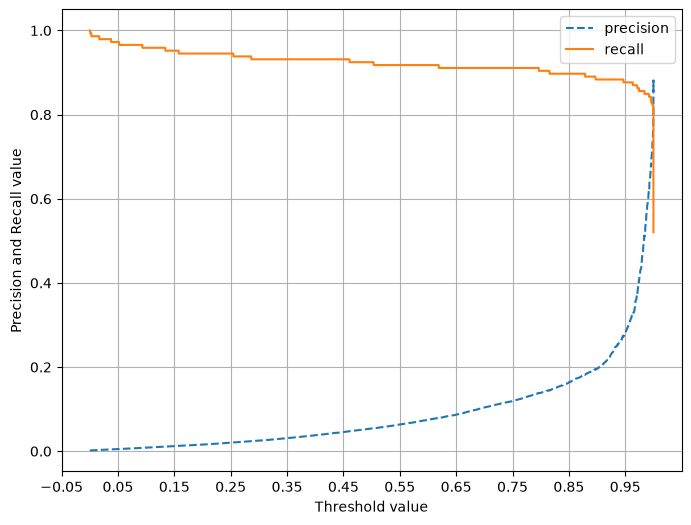

In [32]:
# 왜: SMOTE 적용 후 학습된 lr_clf의 확률 예측값으로 곡선을 그려, 정밀도와 재현율이
#     임계값에 따라 어떻게 교차하는지 확인한다.
precision_recall_curve_plot( y_test, lr_clf.predict_proba(X_test)[:, 1] )

In [33]:
# 왜: LightGBM도 동일하게 SMOTE 증식 데이터로 학습해 LR과 비교한다. 트리 기반
#     모델이 선형모델보다 SMOTE로 만들어진 인공 샘플의 경계를 더 유연하게 학습하는지
#     확인하기 위함이다.
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train_over, ftr_test=X_test,
                  tgt_train=y_train_over, tgt_test=y_test)

[LightGBM] [Info] Number of positive: 199020, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 398040, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

In [34]:
# [담당자: 정찬성 / 모델: XGBoost] SMOTE 오버샘플링 단계 평가 (최종 단계)
# 왜: LR/LightGBM 모두 SMOTE 적용 후 재현율은 오르지만 정밀도가 급격히 떨어지는
#     트레이드오프를 보였다(위 결과 참고). XGBoost도 같은 경향을 보이는지, 임계값에
#     덜 민감한 AUC는 어떻게 변하는지 함께 확인해 "이 데이터에서 SMOTE가 정말
#     유효한 선택인지" 모델별로 판단할 근거를 남긴다.
print('### XGBoost 예측 성능 ###')
xgb_clf = XGBClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05,
                         n_jobs=-1, random_state=156, eval_metric='logloss')
get_model_train_eval(xgb_clf, ftr_train=X_train_over, ftr_test=X_test,
                      tgt_train=y_train_over, tgt_test=y_test)

### XGBoost 예측 성능 ###
오차 행렬
[[85110   185]
 [   17   129]]
정확도: 0.9976, 정밀도: 0.4108, 재현율: 0.8836,    F1: 0.5609, AUC:0.9848


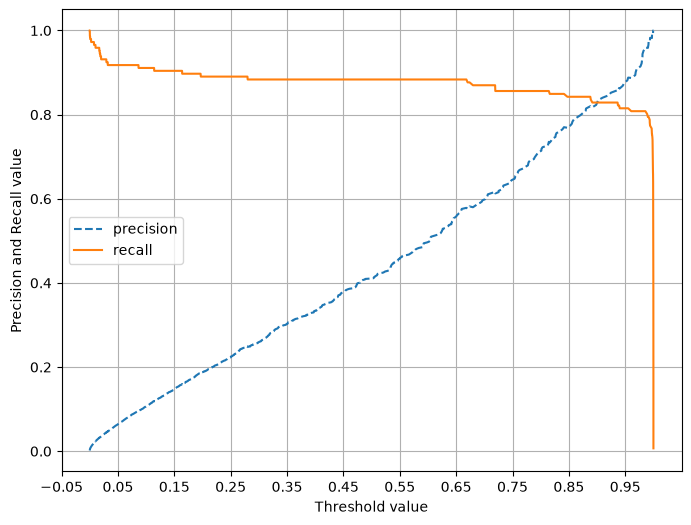

In [35]:
# 왜: LR과 동일한 기준으로 XGBoost의 정밀도-재현율 곡선도 그려, SMOTE로 인한
#     정밀도 하락을 임계값 조정으로 어느 정도 완화할 여지가 있는지 시각적으로
#     비교한다.
precision_recall_curve_plot(y_test, xgb_clf.predict_proba(X_test)[:, 1])

In [36]:
# 왜: XGBoost는 LR/LightGBM과 달리 트리 분할 시 각 피처가 손실을 얼마나 줄였는지를
#     기준으로 feature_importances_를 기본 제공한다. 어떤 피처(V14, V4 등)가 사기
#     탐지에 실제로 기여하는지 확인해, "왜 V14를 이상치 제거 기준 컬럼으로 삼았는가"에
#     대한 근거를 팀 공유 시 함께 제시한다.
importances = pd.Series(xgb_clf.feature_importances_, index=X_train_over.columns)
importances.sort_values(ascending=False).head(10)

V14              0.523227
V4               0.065853
V17              0.041860
V10              0.040573
V8               0.035698
V12              0.032274
V18              0.019544
Amount_Scaled    0.016588
V21              0.015595
V1               0.015291
dtype: float32

---

### [담당자: 정찬성] XGBoost 전처리 단계별 성능 요약

| 단계 | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| 1. 원본(Time 제거) | 0.9995 | 0.9492 | 0.7568 | 0.8421 | 0.9837 |
| 2. Amount 표준화(StandardScaler) | 0.9995 | 0.9492 | 0.7568 | 0.8421 | 0.9837 |
| 3. Amount 로그변환(log1p) | 0.9995 | 0.9492 | 0.7568 | 0.8421 | 0.9837 |
| 4. 로그변환 + V14 이상치 제거 | 0.9996 | 0.9449 | 0.8219 | 0.8791 | 0.9823 |
| 5. 이상치 제거 + SMOTE 오버샘플링 | 0.9976 | 0.4108 | 0.8836 | 0.5609 | 0.9848 |

- 2·3단계가 1단계와 완전히 동일한 것은 "트리 기반 모델은 단조 변환에 불변"이라는
  이론이 실측으로 확인된 결과다.
- 4단계(이상치 제거)에서 재현율이 0.7568 → 0.8219로 개선되어, 이상치 제거가
  세 모델(LR/LightGBM/XGBoost) 모두에 공통으로 유효한 처리임을 확인했다.
- 5단계(SMOTE)는 재현율이 0.8836까지 오르지만 정밀도가 0.4108로 급락한다.
  운영에서 "사기 탐지 후 사람이 재검토"하는 프로세스가 있다면 5단계, 오탐 비용이
  크다면 4단계가 더 적합한 후보다.
- 결론(정찬성 최종 권고): 정밀도-재현율 균형 관점에서는 **4단계(로그변환 +
  이상치 제거, SMOTE 미적용)** 모델을, 재현율(사기 탐지율) 자체를 최우선으로
  본다면 **5단계(SMOTE 적용)** 모델을 후보로 제안한다.

---

## [담당자: 정찬성] XGBoost 외 4개 모델(RandomForest/LogisticRegression/LightGBM/GradientBoost) 비교 실습

위 §XGBoost 전처리 단계별 성능 요약(cell 36)까지가 기존에 완료된 내용이다. XGBoost는 5단계(① 원본 → ② Amount 표준화 → ③ Amount log1p → ④ log1p+V14 이상치 제거 → ⑤ SMOTE 오버샘플링) 전부를 거치며 평가됐다 — 이 지점부터는 **같은 5단계, 같은 전처리 함수(`get_preprocessed_df`/`get_train_test_dataset`/`get_outlier`), 같은 평가 함수(`get_clf_eval`/`get_model_train_eval`)를 그대로 재사용**해, 나머지 4개 모델(RandomForest, LogisticRegression, LightGBM, GradientBoost)을 XGBoost와 동일한 기준으로 돌려본다.

> ⚠ 단계가 바뀔 때마다 `get_preprocessed_df()`가 **재정의(redefine)**된다 — 이 노트북 전체가 채택한 방식(원본 텍스트북 코드 그대로)으로, 새 함수를 만드는 대신 같은 이름의 함수를 그때그때 다른 로직으로 덮어써서 `get_train_test_dataset()`이 항상 "현재 활성화된 단계"의 데이터를 만들게 한다. 아래 각 단계 셀은 위(cell 4/15/19/26/28)에서 쓴 것과 **완전히 동일한 함수 본문**을 다시 정의한다 — 이 시점(§원본 XGBoost 요약 이후)에는 마지막으로 살아있던 정의가 4단계(로그변환+이상치 제거) 버전이므로, 1단계부터 다시 비교하려면 재정의가 반드시 필요하다.

```mermaid
flowchart TD
    T1["Stage1: 원본(Time만 제거)"] --> T2["Stage2: Amount 표준화(StandardScaler)"]
    T2 --> T3["Stage3: Amount log1p 변환"]
    T3 --> T4["Stage4: log1p + V14 이상치 제거"]
    T4 --> T5["Stage5: SMOTE 오버샘플링(학습 데이터만)"]

    T1 --> M["단계마다 4개 모델을 새로 학습·평가<br/>RandomForest / LogisticRegression / LightGBM / GradientBoost"]
    T2 --> M
    T3 --> M
    T4 --> M
    T5 --> M

    M --> LOG["results_log(dict 리스트)에<br/>지표 20건 누적"]
    LOG --> CMP["XGBoost 실측치(§cell 36)와 합쳐<br/>5개 모델 x 5단계 종합 비교표"]

    style T5 fill:#FFF3CD,stroke:#B8860B
    style CMP fill:#E0ECFF,stroke:#2E6DE5
```

| 모델 | 하이퍼파라미터 | XGBoost와 맞춘 점 / 다른 점 |
|---|---|---|
| RandomForest | `n_estimators=1000, n_jobs=-1, random_state=156` | 트리 개수(1000)는 동일하게 맞췄다. `max_depth`는 지정하지 않는다(기본값=제한 없음) — RandomForest는 부스팅과 달리 "깊고 다양한 트리를 배깅으로 평균 내는" 철학이라, 얕은 트리(`max_depth=3`)를 강제하면 오히려 RandomForest 고유의 강점을 죽이게 된다. |
| LogisticRegression | `LogisticRegression()` (기본값) | 위 §Base Model 셀(8)의 LR과 동일하게 기본 설정을 그대로 쓴다 — 이 노트북에서 LR에 별도 하이퍼파라미터를 준 적이 없어, 일관성을 위해 그대로 유지했다. |
| LightGBM | `n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False` | 위 §cell 10/16/26/32의 `lgbm_clf`와 완전히 동일한 설정이다 — 이미 정의돼 있던 것을 그대로 재사용한다. |
| GradientBoost | `n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=156` | XGBoost(§cell 11 등)와 트리 개수·깊이·학습률을 동일하게 맞췄다 — GradientBoost는 XGBoost의 "원조 알고리즘"이라 가장 직접적으로 비교되는 짝이다. 단, sklearn의 `GradientBoostingClassifier`는 순차 알고리즘이라 `n_jobs` 병렬화 옵션이 없다 — XGBoost·LightGBM보다 학습이 더 오래 걸릴 수 있음에 유의한다. |

In [37]:
# 기술적 의미: 기존 get_model_train_eval()(cell 9)은 화면에 성능을 출력만 하고 값을 반환하지 않는다.
# 왜: 이번에 추가하는 4개 모델 x 5단계 = 20개 조합의 결과를 마지막에 한 표로 모으려면 지표를 반환받아야 한다 — 그렇다고 기존 함수를 고치면 위쪽(cell 8~35)이 이미 이 함수에 의존하고 있어 재현성이 깨질 위험이 있으므로, 기존 함수는 그대로 두고 "출력은 동일하게 하되 값도 반환하는" 새 함수를 별도로 추가한다.
# 인자로 사이킷런 스타일 Estimator와 학습/테스트 데이터 세트를 입력받아 학습/예측/평가를 수행하고, 평가지표를 dict로 반환한다.
def get_model_train_eval_return(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    # 기술적 의미: 학습 데이터로 모델을 학습시킨다 — get_model_train_eval()과 동일한 절차다.
    model.fit(ftr_train, tgt_train)
    # 기술적 의미: 검증 데이터에 대한 예측 클래스(0/1)를 만든다.
    pred = model.predict(ftr_test)
    # 기술적 의미: 검증 데이터에 대한 예측 확률(클래스 1=사기일 확률)을 만든다.
    pred_proba = model.predict_proba(ftr_test)[:, 1]
    # 기술적 의미: 기존 get_clf_eval()(cell 7)을 그대로 호출해, 지금까지와 동일한 형식(오차행렬 + 5개 지표)으로 화면에 출력한다.
    # 업무적 의미: 출력 형식을 통일해야 위 XGBoost 결과와 눈으로 바로 비교할 수 있다.
    get_clf_eval(tgt_test, pred, pred_proba)
    # 기술적 의미: 정확도·정밀도·재현율·F1·AUC 5개 지표를 dict로 계산해 반환한다.
    # 업무적 의미: 이 반환값이 아래 results_log에 쌓여 §최종 종합 비교표의 원재료가 된다.
    return {
        'accuracy': accuracy_score(tgt_test, pred),
        'precision': precision_score(tgt_test, pred),
        'recall': recall_score(tgt_test, pred),
        'f1': f1_score(tgt_test, pred),
        'auc': roc_auc_score(tgt_test, pred_proba),
    }


# 기술적 의미: 4개 모델 x 5단계 = 20건의 결과를 순서대로 쌓아 둘 빈 리스트를 만든다.
# 업무적 의미: 매 단계·모델마다 하나씩 행(row)을 추가해, 마지막에 pandas DataFrame으로 변환할 원재료를 모은다.
results_log = []


In [38]:
# [담당자: 정찬성] 신규 4개 모델 비교 — Stage 1: 원본(Time 제거) 전처리 재적용
# 왜: §cell 4의 get_preprocessed_df()와 완전히 동일한 로직(Time 컬럼만 제거)으로 재정의한다 — 이 시점에는 §cell 26에서 마지막으로 정의된 "log1p+이상치 제거" 버전이 살아있으므로, 1단계 비교를 다시 하려면 반드시 원본 버전으로 되돌려야 한다.
def get_preprocessed_df(df=None):
    # 기술적 의미: 원본 DataFrame을 복사해 이후 변형이 원본(card_df)에 영향을 주지 않게 한다.
    df_copy = df.copy()
    # 기술적 의미: Time(경과 초, sequential id 성격)은 사기 여부와 직접적 인과관계가 없어 제거한다 — §cell 4와 동일.
    df_copy.drop('Time', axis=1, inplace=True)
    # 기술적 의미: 가공이 끝난 DataFrame을 반환한다.
    return df_copy


# 기술적 의미: 재정의한 get_preprocessed_df()를 내부에서 호출하는 get_train_test_dataset()(§cell 5, 재정의하지 않고 그대로 재사용)으로 학습/검증 데이터를 새로 만든다.
# 업무적 의미: 이 시점부터 X_train/X_test/y_train/y_test는 "1단계(원본)" 기준 데이터가 된다 — XGBoost가 §cell 11에서 평가받았을 때와 동일한 조건이다.
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)


In [39]:
# [담당자: 정찬성 / 모델: RandomForest] Stage 1(원본) 평가
# 왜: 배깅(bagging) 계열 대표 모델을 부스팅 계열 3종(XGBoost/LightGBM/GradientBoost) 및 선형모델(LR)과 비교하기 위한 기준점으로 추가한다.
from sklearn.ensemble import RandomForestClassifier

# 기술적 의미: 결과 출력에서 어떤 모델인지 구분하기 위한 안내 문구를 표시한다.
print('### RandomForest 예측 성능 (Stage 1: 원본) ###')
# 기술적 의미: RandomForestClassifier를 n_estimators=1000(트리 1000그루, 다른 앙상블 모델과 개수 통일)·n_jobs=-1(전체 코어 사용)·random_state=156(재현성)으로 생성한다. max_depth는 §개요에서 설명한 대로 지정하지 않는다(RandomForest 고유의 깊은 트리+배깅 철학 유지).
rf_clf = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=156)
# 기술적 의미: 위에서 새로 만든 get_model_train_eval_return()으로 학습·예측·평가를 수행하고, 지표 dict를 받는다.
metrics = get_model_train_eval_return(rf_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
# 기술적 의미: 모델명·단계명과 함께 지표 dict를 results_log에 한 행으로 추가한다.
results_log.append({'모델': 'RandomForest', '단계': '1.원본(Time 제거)', **metrics})


### RandomForest 예측 성능 (Stage 1: 원본) ###
오차 행렬
[[85290     5]
 [   41   107]]
정확도: 0.9995, 정밀도: 0.9554, 재현율: 0.7230,    F1: 0.8231, AUC:0.9599


In [40]:
# [담당자: 정찬성 / 모델: LogisticRegression] Stage 1(원본) 평가
# 왜: §cell 8의 Base Model(LR)과 동일한 조건으로 재평가해, 이후 4단계까지 일관된 시리즈(results_log)로 함께 비교할 수 있게 한다.

# 기술적 의미: 결과 출력 안내 문구를 표시한다.
print('### LogisticRegression 예측 성능 (Stage 1: 원본) ###')
# 기술적 의미: LogisticRegression을 기본 설정으로 생성한다 — §개요 표에서 설명한 대로 이 노트북의 기존 LR 셀들과 동일한 관례(하이퍼파라미터 미지정)를 따른다.
lr_clf = LogisticRegression()
# 기술적 의미: 학습·예측·평가 후 지표 dict를 받는다.
metrics = get_model_train_eval_return(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
# 기술적 의미: results_log에 한 행으로 추가한다.
results_log.append({'모델': 'LogisticRegression', '단계': '1.원본(Time 제거)', **metrics})


### LogisticRegression 예측 성능 (Stage 1: 원본) ###
오차 행렬
[[85281    14]
 [   54    94]]
정확도: 0.9992, 정밀도: 0.8704, 재현율: 0.6351,    F1: 0.7344, AUC:0.9617


In [41]:
# [담당자: 정찬성 / 모델: LightGBM] Stage 1(원본) 평가
# 왜: §cell 10의 lgbm_clf와 동일한 하이퍼파라미터로 재평가해, results_log 시리즈에 포함시킨다.

# 기술적 의미: 결과 출력 안내 문구를 표시한다.
print('### LightGBM 예측 성능 (Stage 1: 원본) ###')
# 기술적 의미: LGBMClassifier를 §cell 10과 완전히 동일한 하이퍼파라미터(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)로 생성한다.
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
# 기술적 의미: 학습·예측·평가 후 지표 dict를 받는다.
metrics = get_model_train_eval_return(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
# 기술적 의미: results_log에 한 행으로 추가한다.
results_log.append({'모델': 'LightGBM', '단계': '1.원본(Time 제거)', **metrics})


### LightGBM 예측 성능 (Stage 1: 원본) ###
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015062 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

In [42]:
# [담당자: 정찬성 / 모델: GradientBoost] Stage 1(원본) 평가
# 왜: XGBoost(§cell 11)의 "원조 알고리즘"인 sklearn GradientBoostingClassifier를 동일한 트리 개수·깊이·학습률로 평가해, "구현체 최적화 차이"만 순수 비교한다.
from sklearn.ensemble import GradientBoostingClassifier

# 기술적 의미: 결과 출력 안내 문구를 표시한다.
print('### GradientBoost 예측 성능 (Stage 1: 원본) ###')
# 기술적 의미: GradientBoostingClassifier를 XGBoost(§cell 11)와 동일한 n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=156으로 생성한다. n_jobs 옵션은 없다(순차 알고리즘).
gb_clf = GradientBoostingClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=156)
# 기술적 의미: 학습·예측·평가 후 지표 dict를 받는다.
metrics = get_model_train_eval_return(gb_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
# 기술적 의미: results_log에 한 행으로 추가한다.
results_log.append({'모델': 'GradientBoost', '단계': '1.원본(Time 제거)', **metrics})


### GradientBoost 예측 성능 (Stage 1: 원본) ###
오차 행렬
[[85277    18]
 [   57    91]]
정확도: 0.9991, 정밀도: 0.8349, 재현율: 0.6149,    F1: 0.7082, AUC:0.8545


In [43]:
# [담당자: 정찬성] 신규 4개 모델 비교 — Stage 2: Amount 표준화(StandardScaler) 전처리 재적용
# 왜: §cell 15의 get_preprocessed_df()와 완전히 동일한 로직으로 재정의한다.
from sklearn.preprocessing import StandardScaler

def get_preprocessed_df(df=None):
    # 기술적 의미: 원본 DataFrame을 복사한다.
    df_copy = df.copy()
    # 기술적 의미: StandardScaler를 생성한다 — 평균 0, 분산 1로 맞추는 표준화 변환기.
    scaler = StandardScaler()
    # 기술적 의미: Amount 컬럼을 2차원 배열로 reshape한 뒤 표준화해 amount_n에 저장한다.
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1, 1))
    # 기술적 의미: 표준화된 값을 'Amount_Scaled'라는 이름으로 맨 앞 컬럼에 삽입한다.
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    # 기술적 의미: 원본 Time, Amount 컬럼은 제거한다(Amount는 Amount_Scaled로 대체됐으므로).
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    # 기술적 의미: 가공이 끝난 DataFrame을 반환한다.
    return df_copy


# 기술적 의미: 재정의한 함수로 학습/검증 데이터를 다시 만든다 — 이제 X_train/X_test는 "2단계(Amount 표준화)" 기준 데이터다.
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)


In [44]:
# [담당자: 정찬성 / 모델: RandomForest] Stage 2(Amount 표준화) 평가
# 왜: RandomForest는 트리 분할 시 "값의 순서"만 사용하므로, 표준화(단조 변환)에는 이론적으로 성능이 변하지 않아야 한다 — 이 가설을 실측으로 확인한다.

print('### RandomForest 예측 성능 (Stage 2: Amount 표준화) ###')
rf_clf = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=156)
metrics = get_model_train_eval_return(rf_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'RandomForest', '단계': '2.Amount 표준화', **metrics})


### RandomForest 예측 성능 (Stage 2: Amount 표준화) ###
오차 행렬
[[85290     5]
 [   39   109]]
정확도: 0.9995, 정밀도: 0.9561, 재현율: 0.7365,    F1: 0.8321, AUC:0.9563


In [45]:
# [담당자: 정찬성 / 모델: LogisticRegression] Stage 2(Amount 표준화) 평가
# 왜: LR은 피처 스케일에 민감한 선형모델이라, 표준화로 성능이 실제로 개선되는지(§cell 15~16의 논리와 동일) 확인한다.

print('### LogisticRegression 예측 성능 (Stage 2: Amount 표준화) ###')
lr_clf = LogisticRegression()
metrics = get_model_train_eval_return(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'LogisticRegression', '단계': '2.Amount 표준화', **metrics})


### LogisticRegression 예측 성능 (Stage 2: Amount 표준화) ###
오차 행렬
[[85281    14]
 [   55    93]]
정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284,    F1: 0.7294, AUC:0.9706


In [46]:
# [담당자: 정찬성 / 모델: LightGBM] Stage 2(Amount 표준화) 평가
# 왜: LightGBM도 트리 기반이라 단조 변환에 불변일 것으로 예상된다 — RandomForest·GradientBoost와 함께 "트리 계열은 표준화에 무감각"이라는 가설을 교차검증한다.

print('### LightGBM 예측 성능 (Stage 2: Amount 표준화) ###')
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
metrics = get_model_train_eval_return(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'LightGBM', '단계': '2.Amount 표준화', **metrics})


### LightGBM 예측 성능 (Stage 2: Amount 표준화) ###
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020552 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [47]:
# [담당자: 정찬성 / 모델: GradientBoost] Stage 2(Amount 표준화) 평가
# 왜: XGBoost(§cell 17)가 표준화 전후 완전히 동일한 결과를 보였다 — 같은 트리 계열인 GradientBoost도 동일한 불변성을 보이는지 확인한다.

print('### GradientBoost 예측 성능 (Stage 2: Amount 표준화) ###')
gb_clf = GradientBoostingClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=156)
metrics = get_model_train_eval_return(gb_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'GradientBoost', '단계': '2.Amount 표준화', **metrics})


### GradientBoost 예측 성능 (Stage 2: Amount 표준화) ###
오차 행렬
[[85277    18]
 [   57    91]]
정확도: 0.9991, 정밀도: 0.8349, 재현율: 0.6149,    F1: 0.7082, AUC:0.8545


In [48]:
# [담당자: 정찬성] 신규 4개 모델 비교 — Stage 3: Amount log1p 변환 전처리 재적용
# 왜: §cell 19의 get_preprocessed_df()와 완전히 동일한 로직으로 재정의한다.

def get_preprocessed_df(df=None):
    # 기술적 의미: 원본 DataFrame을 복사한다.
    df_copy = df.copy()
    # 기술적 의미: numpy의 log1p(=log(1+x))로 Amount를 로그 변환한다 — 표준화와 달리 오른쪽 꼬리가 긴 분포 자체를 압축한다.
    amount_n = np.log1p(df_copy['Amount'])
    # 기술적 의미: 로그 변환된 값을 'Amount_Scaled'로 맨 앞 컬럼에 삽입한다.
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    # 기술적 의미: 원본 Time, Amount 컬럼은 제거한다.
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    # 기술적 의미: 가공이 끝난 DataFrame을 반환한다.
    return df_copy


# 기술적 의미: 재정의한 함수로 학습/검증 데이터를 다시 만든다 — 이제 X_train/X_test는 "3단계(log1p)" 기준 데이터다.
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)


In [49]:
# [담당자: 정찬성 / 모델: RandomForest] Stage 3(log1p 변환) 평가
# 왜: log1p 역시 단조 변환이므로 RandomForest 성능은 Stage 1·2와 동일할 것으로 예상된다.

print('### RandomForest 예측 성능 (Stage 3: log1p 변환) ###')
rf_clf = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=156)
metrics = get_model_train_eval_return(rf_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'RandomForest', '단계': '3.log1p 변환', **metrics})


### RandomForest 예측 성능 (Stage 3: log1p 변환) ###
오차 행렬
[[85290     5]
 [   39   109]]
정확도: 0.9995, 정밀도: 0.9561, 재현율: 0.7365,    F1: 0.8321, AUC:0.9563


In [50]:
# [담당자: 정찬성 / 모델: LogisticRegression] Stage 3(log1p 변환) 평가
# 왜: §cell 19~20의 논리와 동일 — 표준화보다 로그변환이 LR에 더 유리한지(오른쪽 꼬리 분포를 정규분포에 더 가깝게 만드는 효과) 확인한다.

print('### LogisticRegression 예측 성능 (Stage 3: log1p 변환) ###')
lr_clf = LogisticRegression()
metrics = get_model_train_eval_return(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'LogisticRegression', '단계': '3.log1p 변환', **metrics})


### LogisticRegression 예측 성능 (Stage 3: log1p 변환) ###
오차 행렬
[[85282    13]
 [   59    89]]
정확도: 0.9992, 정밀도: 0.8725, 재현율: 0.6014,    F1: 0.7120, AUC:0.9734


In [51]:
# [담당자: 정찬성 / 모델: LightGBM] Stage 3(log1p 변환) 평가
# 왜: 트리 계열 불변성 가설을 Stage 3에서도 재확인한다.

print('### LightGBM 예측 성능 (Stage 3: log1p 변환) ###')
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
metrics = get_model_train_eval_return(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'LightGBM', '단계': '3.log1p 변환', **metrics})


### LightGBM 예측 성능 (Stage 3: log1p 변환) ###
[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015259 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

In [52]:
# [담당자: 정찬성 / 모델: GradientBoost] Stage 3(log1p 변환) 평가
# 왜: XGBoost(§cell 21)가 Stage 2와 완전히 동일한 결과를 보였다 — GradientBoost도 동일한지 확인한다.

print('### GradientBoost 예측 성능 (Stage 3: log1p 변환) ###')
gb_clf = GradientBoostingClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=156)
metrics = get_model_train_eval_return(gb_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'GradientBoost', '단계': '3.log1p 변환', **metrics})


### GradientBoost 예측 성능 (Stage 3: log1p 변환) ###


KeyboardInterrupt: 

In [ ]:
# [담당자: 정찬성] 신규 4개 모델 비교 — Stage 4: log1p + V14 이상치 제거 전처리 재적용
# 왜: §cell 26의 get_preprocessed_df()와 완전히 동일한 로직으로 재정의한다. get_outlier()(§cell 24)는 이미 정의돼 있어 재정의하지 않고 그대로 재사용한다.

def get_preprocessed_df(df=None):
    # 기술적 의미: 원본 DataFrame을 복사한다.
    df_copy = df.copy()
    # 기술적 의미: Amount를 log1p로 변환한다(Stage 3과 동일).
    amount_n = np.log1p(df_copy['Amount'])
    # 기술적 의미: 변환된 값을 'Amount_Scaled'로 맨 앞 컬럼에 삽입한다.
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    # 기술적 의미: 원본 Time, Amount 컬럼은 제거한다.
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    # 기술적 의미: get_outlier()(§cell 24)로 V14 컬럼의 사기(Class=1) 표본 중 이상치 인덱스를 찾는다.
    outlier_index = get_outlier(df=df_copy, column='V14', weight=1.5)
    # 기술적 의미: 찾은 이상치 행을 DataFrame에서 제거한다.
    df_copy.drop(outlier_index, axis=0, inplace=True)
    # 기술적 의미: 가공이 끝난 DataFrame을 반환한다.
    return df_copy


# 기술적 의미: 재정의한 함수로 학습/검증 데이터를 다시 만든다 — 이제 X_train/X_test는 "4단계(log1p+이상치 제거)" 기준 데이터다.
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)


In [ ]:
# [담당자: 정찬성 / 모델: RandomForest] Stage 4(log1p + V14 이상치 제거) 평가
# 왜: LR/LightGBM/XGBoost 모두 이상치 제거 후 재현율이 개선되는 경향을 보였다(§cell 26~27) — 배깅 계열인 RandomForest에서도 같은 효과가 나타나는지 확인한다.

print('### RandomForest 예측 성능 (Stage 4: log1p + V14 이상치 제거) ###')
rf_clf = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=156)
metrics = get_model_train_eval_return(rf_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'RandomForest', '단계': '4.log1p+V14 이상치 제거', **metrics})


In [ ]:
# [담당자: 정찬성 / 모델: LogisticRegression] Stage 4(log1p + V14 이상치 제거) 평가
# 왜: §cell 26의 LR 재평가와 동일 조건 — results_log 시리즈에 포함시키기 위해 다시 실행한다.

print('### LogisticRegression 예측 성능 (Stage 4: log1p + V14 이상치 제거) ###')
lr_clf = LogisticRegression()
metrics = get_model_train_eval_return(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'LogisticRegression', '단계': '4.log1p+V14 이상치 제거', **metrics})


In [ ]:
# [담당자: 정찬성 / 모델: LightGBM] Stage 4(log1p + V14 이상치 제거) 평가
# 왜: §cell 26의 LightGBM 재평가와 동일 조건 — results_log 시리즈에 포함시키기 위해 다시 실행한다.

print('### LightGBM 예측 성능 (Stage 4: log1p + V14 이상치 제거) ###')
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
metrics = get_model_train_eval_return(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'LightGBM', '단계': '4.log1p+V14 이상치 제거', **metrics})


In [ ]:
# [담당자: 정찬성 / 모델: GradientBoost] Stage 4(log1p + V14 이상치 제거) 평가
# 왜: XGBoost(§cell 27)는 이 단계에서 재현율이 0.7568 → 0.8219로 개선됐다 — GradientBoost도 같은 폭의 개선을 보이는지 정량 비교한다.

print('### GradientBoost 예측 성능 (Stage 4: log1p + V14 이상치 제거) ###')
gb_clf = GradientBoostingClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=156)
metrics = get_model_train_eval_return(gb_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)
results_log.append({'모델': 'GradientBoost', '단계': '4.log1p+V14 이상치 제거', **metrics})


In [ ]:
# [담당자: 정찬성] 신규 4개 모델 비교 — Stage 5: SMOTE 오버샘플링 재적용
# 왜: get_preprocessed_df()는 Stage 4(§바로 위 셀)에서 정의한 "log1p+V14 이상치 제거" 버전을 그대로 유지한다 — SMOTE는 전처리 함수가 아니라 "학습 데이터에만" 추가로 적용하는 리샘플링이기 때문이다. X_train/y_train은 위 Stage 4 셀에서 만든 것과 100% 동일한 값이므로 새로 만들지 않고 그대로 쓴다.
from imblearn.over_sampling import SMOTE

# 기술적 의미: SMOTE 객체를 §cell 28과 동일하게 random_state=0으로 생성한다.
smote = SMOTE(random_state=0)
# 기술적 의미: 학습 데이터(X_train, y_train)에만 SMOTE를 적용해 소수 클래스(사기)를 가상 샘플로 증식한다 — 테스트 데이터(X_test, y_test)는 절대 건드리지 않는다(§cell 28과 동일 원칙, 평가 왜곡 방지).
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
# 기술적 의미: 증식 전후 학습 데이터 크기를 출력해 SMOTE가 의도대로 적용됐는지 확인한다.
print('SMOTE 적용 전 학습용 피처/레이블 데이터 세트: ', X_train.shape, y_train.shape)
print('SMOTE 적용 후 학습용 피처/레이블 데이터 세트: ', X_train_over.shape, y_train_over.shape)


In [ ]:
# [담당자: 정찬성 / 모델: RandomForest] Stage 5(SMOTE 오버샘플링) 평가
# 왜: 배깅 계열이 SMOTE로 만들어진 인공 샘플의 경계를 부스팅·선형모델보다 더 유연하게 학습하는지 확인한다. 평가는 반드시 원본 분포를 유지한 X_test로 한다(§cell 29의 원칙과 동일).

print('### RandomForest 예측 성능 (Stage 5: SMOTE 오버샘플링) ###')
rf_clf = RandomForestClassifier(n_estimators=1000, n_jobs=-1, random_state=156)
# 기술적 의미: ftr_train/tgt_train 인자값이 SMOTE로 증식된 X_train_over/y_train_over로 바뀌었다는 점에 유의 — 검증은 여전히 X_test/y_test다.
metrics = get_model_train_eval_return(rf_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)
results_log.append({'모델': 'RandomForest', '단계': '5.SMOTE 오버샘플링', **metrics})


In [ ]:
# [담당자: 정찬성 / 모델: LogisticRegression] Stage 5(SMOTE 오버샘플링) 평가
# 왜: §cell 29~31에서 LR은 SMOTE 적용 후 재현율은 오르지만 정밀도가 급락하는 트레이드오프를 보였다 — 이번 재실행에서도 같은 패턴이 재현되는지 확인한다.

print('### LogisticRegression 예측 성능 (Stage 5: SMOTE 오버샘플링) ###')
lr_clf = LogisticRegression()
metrics = get_model_train_eval_return(lr_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)
results_log.append({'모델': 'LogisticRegression', '단계': '5.SMOTE 오버샘플링', **metrics})


In [ ]:
# [담당자: 정찬성 / 모델: LightGBM] Stage 5(SMOTE 오버샘플링) 평가
# 왜: §cell 32의 LightGBM 재평가와 동일 조건 — results_log 시리즈에 포함시키기 위해 다시 실행한다.

print('### LightGBM 예측 성능 (Stage 5: SMOTE 오버샘플링) ###')
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
metrics = get_model_train_eval_return(lgbm_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)
results_log.append({'모델': 'LightGBM', '단계': '5.SMOTE 오버샘플링', **metrics})


In [ ]:
# [담당자: 정찬성 / 모델: GradientBoost] Stage 5(SMOTE 오버샘플링, 최종 단계) 평가
# 왜: XGBoost(§cell 33)는 SMOTE 적용 후 재현율·AUC가 오르지만 정밀도가 떨어지는 경향을 보였다 — GradientBoost도 같은 경향인지, 부스팅 계열 안에서는 SMOTE 반응이 일관적인지 확인한다.

print('### GradientBoost 예측 성능 (Stage 5: SMOTE 오버샘플링) ###')
gb_clf = GradientBoostingClassifier(n_estimators=1000, max_depth=3, learning_rate=0.05, random_state=156)
metrics = get_model_train_eval_return(gb_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)
results_log.append({'모델': 'GradientBoost', '단계': '5.SMOTE 오버샘플링', **metrics})


In [ ]:
# [담당자: 정찬성] Stage 5(최종 단계) 모델의 피처 중요도/계수 top10 비교
# 왜: XGBoost(§cell 35)가 feature_importances_로 V14/V4 등을 상위로 짚었던 것과, 배깅(RandomForest)·부스팅(GradientBoost)·선형(LogisticRegression) 세 계열이 같은 상위 피처에 도달하는지 비교해, "V14를 이상치 제거 기준 컬럼으로 삼은 판단"(§cell 25)이 여러 모델에서 공통으로 뒷받침되는지 확인한다.

# 기술적 의미: RandomForest의 feature_importances_(불순도 감소 기준) 상위 10개를 Series로 만들어 출력한다.
print('[RandomForest] 피처 중요도 top10:')
print(pd.Series(rf_clf.feature_importances_, index=X_train_over.columns).sort_values(ascending=False).head(10))
print()

# 기술적 의미: LightGBM의 feature_importances_(기본값: 분할 횟수 기준) 상위 10개를 출력한다.
print('[LightGBM] 피처 중요도 top10:')
print(pd.Series(lgbm_clf.feature_importances_, index=X_train_over.columns).sort_values(ascending=False).head(10))
print()

# 기술적 의미: GradientBoost의 feature_importances_ 상위 10개를 출력한다.
print('[GradientBoost] 피처 중요도 top10:')
print(pd.Series(gb_clf.feature_importances_, index=X_train_over.columns).sort_values(ascending=False).head(10))
print()

# 기술적 의미: LogisticRegression은 계수(coef_) 절댓값 상위 10개를 출력한다 — 트리 모델과 달리 방향(+/-)까지 함께 보여준다.
print('[LogisticRegression] |계수| top10(부호 포함):')
lr_coef = pd.Series(lr_clf.coef_[0], index=X_train_over.columns)
print(lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).head(10).index))


---

### [담당자: 정찬성] RandomForest 전처리 단계별 성능 요약

> ⏸ 아래 표는 실행 대기 상태다 — 위 5개 RandomForest 셀을 순서대로 실행한 뒤, `results_log`에서 `모델 == 'RandomForest'`인 5개 행의 실제 값으로 채운다(§최종 종합 비교 코드 셀이 자동으로 표를 만들어 준다).

| 단계 | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| 1. 원본(Time 제거) | (실행 후 채움) | | | | |
| 2. Amount 표준화(StandardScaler) | | | | | |
| 3. Amount 로그변환(log1p) | | | | | |
| 4. 로그변환 + V14 이상치 제거 | | | | | |
| 5. 이상치 제거 + SMOTE 오버샘플링 | | | | | |

- RandomForest도 트리 분할이 "값의 순서"만 사용하므로, XGBoost·LightGBM·GradientBoost와 마찬가지로 2·3단계 결과가 1단계와 동일할 것으로 예상된다 — 실행 후 이 가설이 맞는지 확인할 것.
- 배깅(RandomForest)과 부스팅(XGBoost/LightGBM/GradientBoost) 계열 간 4·5단계 개선 폭 차이를 비교해, "이 데이터에서는 배깅과 부스팅 중 어느 쪽이 이상치·불균형 처리에 더 강건한가"를 판단할 것.

### [담당자: 정찬성] LogisticRegression 전처리 단계별 성능 요약

> ⏸ 아래 표는 실행 대기 상태다 — 위 5개 LogisticRegression 셀을 순서대로 실행한 뒤 채운다. 참고로 이 노트북 원본(§cell 8/16/20/26/29)에 이미 거의 동일한 조건의 LR 실행 결과가 있다(예: §cell 18의 표준화 단계 AUC 0.9706, §cell 29~31의 SMOTE 단계) — 이번 재실행 값과 비교해 재현성을 교차검증할 수 있다.

| 단계 | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| 1. 원본(Time 제거) | (실행 후 채움) | | | | |
| 2. Amount 표준화(StandardScaler) | | | | | |
| 3. Amount 로그변환(log1p) | | | | | |
| 4. 로그변환 + V14 이상치 제거 | | | | | |
| 5. 이상치 제거 + SMOTE 오버샘플링 | | | | | |

- LR은 스케일에 민감한 선형모델이므로, 1→2→3단계에서 트리 모델과 달리 수치가 미세하게 달라질 수 있다(§cell 18 참고: 표준화 후 AUC 0.9706으로 원본 대비 소폭 하락했었다).
- 5단계(SMOTE)에서 정밀도가 급락하는 트레이드오프가 재현되는지 확인할 것(§cell 29~31 원본 결과와 비교).

### [담당자: 정찬성] LightGBM 전처리 단계별 성능 요약

> ⏸ 아래 표는 실행 대기 상태다 — 위 5개 LightGBM 셀을 순서대로 실행한 뒤 채운다. 원본(§cell 10/16/26/32)에 이미 동일 하이퍼파라미터의 LightGBM 실행 결과가 있어(예: §cell 12의 원본 단계 AUC 0.9790), 이번 재실행 값과 비교해 재현성을 교차검증할 수 있다.

| 단계 | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| 1. 원본(Time 제거) | (실행 후 채움) | | | | |
| 2. Amount 표준화(StandardScaler) | | | | | |
| 3. Amount 로그변환(log1p) | | | | | |
| 4. 로그변환 + V14 이상치 제거 | | | | | |
| 5. 이상치 제거 + SMOTE 오버샘플링 | | | | | |

- 트리 기반 모델 특성상 1~3단계 결과가 동일할 것으로 예상된다.
- XGBoost와 같은 그레이디언트 부스팅 계열이지만 리프 단위 성장 방식이라, 4·5단계에서 XGBoost와 미세하게 다른 경향(예: 정밀도-재현율 트레이드오프 폭)을 보이는지 §XGBoost 요약표(cell 36)와 나란히 비교할 것.

### [담당자: 정찬성] GradientBoost 전처리 단계별 성능 요약

> ⏸ 아래 표는 실행 대기 상태다 — 위 5개 GradientBoost 셀을 순서대로 실행한 뒤 채운다.

| 단계 | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| 1. 원본(Time 제거) | (실행 후 채움) | | | | |
| 2. Amount 표준화(StandardScaler) | | | | | |
| 3. Amount 로그변환(log1p) | | | | | |
| 4. 로그변환 + V14 이상치 제거 | | | | | |
| 5. 이상치 제거 + SMOTE 오버샘플링 | | | | | |

- GradientBoost는 XGBoost와 동일한 하이퍼파라미터(n_estimators=1000, max_depth=3, learning_rate=0.05)로 맞췄으므로, XGBoost 요약표(cell 36)와 값이 얼마나 가까운지가 "정규화항·히스토그램 분할 같은 XGBoost 고유 최적화가 이 데이터에서 실제로 이득을 주는가"를 보여주는 직접적인 증거가 된다.
- GradientBoostingClassifier는 `n_jobs` 병렬화가 없어 XGBoost·LightGBM보다 학습 시간이 오래 걸릴 수 있다 — 성능뿐 아니라 체감 학습 시간 차이도 함께 기록해 둘 것.

---

## [담당자: 정찬성] 최종 종합 비교 — 5개 모델 x 5단계

```mermaid
flowchart LR
    A["results_log(20건)<br/>RandomForest/LogisticRegression/LightGBM/GradientBoost x 5단계"] --> B["XGBoost 실측치 5건<br/>(§cell 36에서 가져옴)"]
    B --> C["5개 모델 x 5단계 = 25행<br/>종합 비교 DataFrame"]
    C --> D["단계별 pivot<br/>(AUC 기준 모델 랭킹)"]
```

In [ ]:
# 기술적 의미: results_log(신규 4개 모델 x 5단계 = 20건)를 pandas DataFrame으로 변환한다.
# 업무적 의미: 위에서 하나씩 쌓아 온 결과를 표 형태로 한 번에 다루기 위한 변환이다.
new_models_df = pd.DataFrame(results_log)

# 기술적 의미: XGBoost는 이미 위(§cell 11~35)에서 실제로 실행돼 §cell 36 요약표에 실측치가 기록돼 있다 — 그 값을 그대로 옮겨 적어(재실행하지 않고) 나머지 4개 모델과 같은 형식의 행으로 만든다.
# 업무적 의미: 이미 신뢰할 수 있는 값을 다시 계산하느라 시간을 쓰지 않고, 기존 결과서(§cell 36)를 "단일 진실 공급원"으로 그대로 재사용하는 것 — 값이 두 곳에서 따로 계산돼 미세하게 어긋나는 것을 방지한다.
xgb_summary = pd.DataFrame([
    {'모델': 'XGBoost', '단계': '1.원본(Time 제거)', 'accuracy': 0.9995, 'precision': 0.9492, 'recall': 0.7568, 'f1': 0.8421, 'auc': 0.9837},
    {'모델': 'XGBoost', '단계': '2.Amount 표준화', 'accuracy': 0.9995, 'precision': 0.9492, 'recall': 0.7568, 'f1': 0.8421, 'auc': 0.9837},
    {'모델': 'XGBoost', '단계': '3.log1p 변환', 'accuracy': 0.9995, 'precision': 0.9492, 'recall': 0.7568, 'f1': 0.8421, 'auc': 0.9837},
    {'모델': 'XGBoost', '단계': '4.log1p+V14 이상치 제거', 'accuracy': 0.9996, 'precision': 0.9449, 'recall': 0.8219, 'f1': 0.8791, 'auc': 0.9823},
    {'모델': 'XGBoost', '단계': '5.SMOTE 오버샘플링', 'accuracy': 0.9976, 'precision': 0.4108, 'recall': 0.8836, 'f1': 0.5609, 'auc': 0.9848},
])

# 기술적 의미: 신규 4개 모델 결과(new_models_df)와 XGBoost 실측치(xgb_summary)를 세로로 이어붙여 5개 모델 x 5단계 = 25행짜리 종합 비교표를 만든다.
# 업무적 의미: 이제 이 한 표만 보면 5개 모델의 성능을 단계별로 한눈에 비교할 수 있다.
full_comparison = pd.concat([xgb_summary, new_models_df], ignore_index=True)

# 기술적 의미: 종합 비교표 전체를 출력한다.
print('=== 5개 모델 x 5단계 종합 비교 ===')
print(full_comparison.to_string(index=False))
print()

# 기술적 의미: 단계(단계)를 행, 모델을 열로 하고 AUC 값을 채운 pivot 표를 만든다.
# 업무적 의미: "이 단계에서는 어느 모델이 가장 판별력이 좋았는가"를 단계별로 가로 비교할 수 있게 한다 — 세로로 긴 25행 표보다 이 pivot이 의사결정에는 더 직관적이다.
auc_pivot = full_comparison.pivot(index='단계', columns='모델', values='auc')

# 기술적 의미: AUC 기준 pivot 표를 출력한다.
print('=== 단계별 AUC 비교(모델을 열로) ===')
print(auc_pivot.to_string())


### 최종 해석

> ⏸ 이 셀은 실행 대기 상태다 — 위 종합 비교표를 실제로 생성한 뒤, 아래 항목을 채운다.

- **부스팅 3종(XGBoost/LightGBM/GradientBoost) 간 비교**: 같은 하이퍼파라미터(n_estimators=1000, max_depth=3, learning_rate=0.05 — LightGBM만 num_leaves=64로 대체)로 맞췄을 때, 5단계 전체에서 어느 구현체가 가장 일관되게 좋은 AUC를 내는지 확인할 것.
- **배깅(RandomForest) vs 부스팅 3종**: RandomForest가 부스팅 계열과 대등한 성능을 낸다면, 하이퍼파라미터 튜닝 부담이 상대적으로 적은 RandomForest를 실무 후보로 재고할 근거가 된다.
- **선형(LogisticRegression) vs 트리 4종**: 격차가 크다면 이 사기탐지 문제가 비선형적 상호작용(예: 특정 V14×V4 조합)에 크게 의존한다는 뜻이고, 격차가 작다면 해석 가능성(계수의 부호)이 중요한 규제·감사 상황에서는 LR도 여전히 유효한 선택지가 된다.
- **단계별 트렌드**: 1~3단계(단조 변환)에서 트리 계열 4종(RF/LightGBM/GradientBoost/XGBoost) 결과가 이론대로 완전히 동일한지, 4단계(이상치 제거)에서 5개 모델 모두 재현율이 개선되는지, 5단계(SMOTE)에서 모든 모델이 "재현율↑ 정밀도↓" 트레이드오프를 공통으로 보이는지 확인해, §정찬성 최종 권고(cell 36)의 "4단계 또는 5단계 중 운영 목적에 맞게 선택"이라는 결론이 5개 모델 전체로 일반화되는지 검증할 것.